In [1]:
import math
from tensorflow import keras
# import keras
from PIL import Image

import numpy as np
np.float_ = np.float64

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "1"
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

# import tensorrt
import tensorflow as tf
gpu_options = tf.compat.v1.GPUOptions(per_process_gpu_memory_fraction=0.98)
sess = tf.compat.v1.Session(config=tf.compat.v1.ConfigProto(gpu_options=gpu_options))
print(tf.config.list_physical_devices('GPU'))


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout, GlobalAveragePooling2D, GlobalMaxPooling2D

from tensorflow.keras.applications.convnext import ConvNeXtXLarge
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from keras.applications.vgg16 import VGG16
from keras.applications.vgg19 import VGG19
from keras.applications.resnet50 import ResNet50

import matplotlib.pyplot as plt
%matplotlib inline 

2025-10-16 10:26:49.730753: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-16 10:26:49.762504: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-16 10:26:50.502090: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1760599610.959587 3255285 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15628 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.9


In [2]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [6]:
# name = 'Dubai'
# name = 'CatDog'

# Каталог с данными для обучения
train_dir = '/media/pendrive/styleclasses/train/'
# Каталог с данными для проверки
val_dir = '/media/pendrive/styleclasses/validation/'
# Каталог с данными для тестирования
# test_dir = f'dataset/test'
# Размеры изображения
img_width, img_height = 224, 224
# Размер мини-выборки
batch_size = 16
# число классов
num_classes = 5

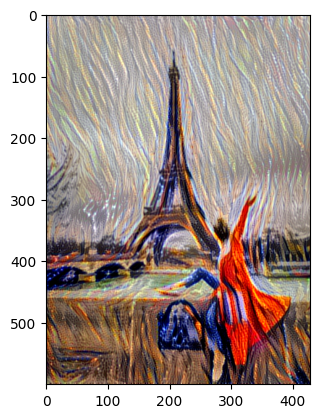

In [10]:
image_file_name = train_dir + '4/5_vgg19_2000_4_at_iteration_1900.png' # with watermark
img = Image.open(image_file_name)
plt.imshow(img)

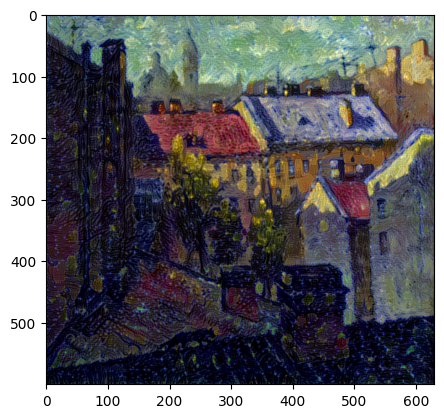

In [12]:
image_file_name = val_dir + '1/3_vgg19_2000_1_at_iteration_1400.png' 
img = Image.open(image_file_name)
plt.imshow(img)

In [13]:
train_datagen = ImageDataGenerator()
# train_datagen = ImageDataGenerator(rescale=1. / 255, featurewise_center=True, featurewise_std_normalization=True)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    # class_mode='binary')
    class_mode='categorical')

Found 1000 images belonging to 5 classes.


In [14]:
test_datagen = ImageDataGenerator()
# test_datagen = ImageDataGenerator(rescale=1. / 255, featurewise_center=True, featurewise_std_normalization=True)
val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    # class_mode='binary')
    class_mode='categorical')

Found 500 images belonging to 5 classes.


In [17]:
def model_maker(activation):

    # base_model = ConvNeXtXLarge(include_top=False, input_shape = (img_width, img_height, 3))
    # base_model = MobileNetV2(include_top=False, input_shape = (img_width, img_height, 3))
    # base_model = VGG16(include_top=False, input_shape = (img_width, img_height, 3))
    # base_model = VGG19(include_top=False, input_shape = (img_width, img_height, 3))
    base_model = ResNet50(include_top=False, input_shape = (img_width, img_height, 3))

    
    for layer in base_model.layers[:]:
        layer.trainable = False # Freeze the layers
        
    input = Input(shape=(img_width, img_height, 3))
    custom_model = base_model(input)
    custom_model = GlobalAveragePooling2D()(custom_model)
    # custom_model = Dense(128, activation='relu')(custom_model)
    # custom_model = Dropout(0.5)(custom_model)
    custom_model = Dense(64, activation='relu')(custom_model)
    # custom_model = Dense(32, activation='relu')(custom_model)
    custom_model = Dropout(0.5)(custom_model)
    predictions = Dense(num_classes, activation=activation)(custom_model) 
    # predictions = Dense(num_classes, activation=activation)(custom_model)
    return Model(inputs=input, outputs=predictions)

In [18]:
# model = model_maker('sigmoid') 
model = model_maker('softmax') 

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,719,173 (90.48 MB)

 Trainable params: 131,461 (513.52 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

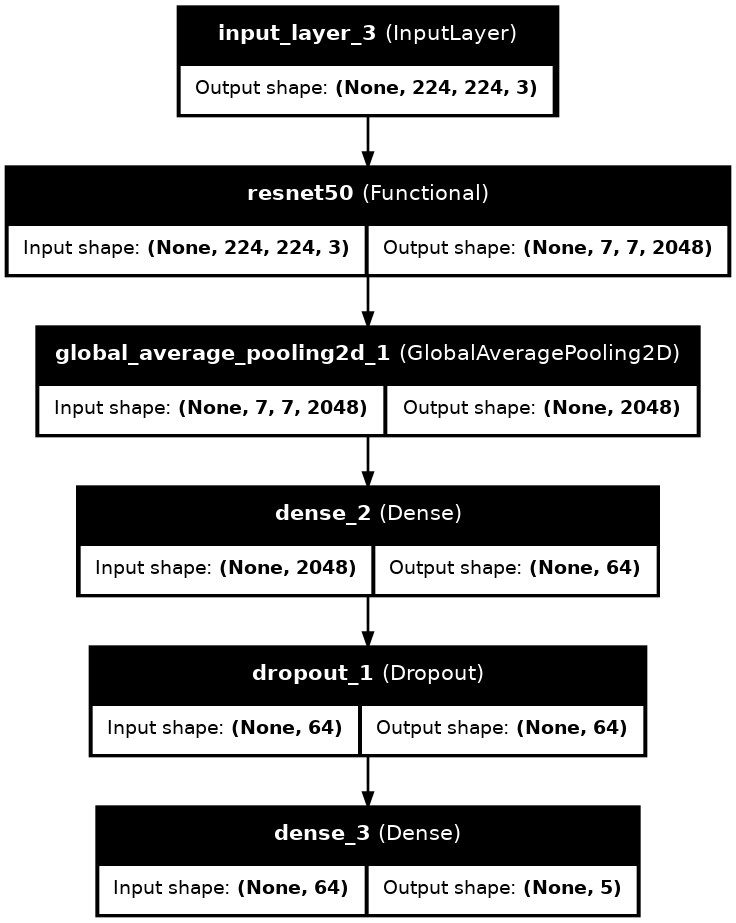

In [20]:
from tensorflow.keras.utils import plot_model
# Визуализация и сохранение графа
plot_model(
    model,
    to_file='classificator.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='TB',  # 'TB' = top to bottom, 'LR' = left to right
    expand_nested=False,
    dpi=96
)

In [21]:
# from keras import metrics
from tensorflow.keras import metrics

#Binary cross entropy of each label. So no really a binary classification problem but
#Calculating binary cross entropy for each label. 
# model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

# model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=[metrics.mae, metrics.categorical_accuracy])
# model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=[metrics.categorical_accuracy])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', # 'categorical_crossentropy',
              metrics=['accuracy',
                       metrics.AUC(name='auc'),
                       metrics.Precision(name='precision'),
                       metrics.Recall(name='recall'),
                       metrics.TruePositives(name='TP'),
                       metrics.TrueNegatives(name='TN'),
                       metrics.FalsePositives(name='FP'),
                       metrics.FalseNegatives(name='FN')])

In [22]:
# Обучаем модель с использованием генераторов
# train_generator - генератор данных для обучения
# validation_data - генератор данных для проверки

callback = tf.keras.callbacks.EarlyStopping(monitor='auc', min_delta=0.01, patience=50)

# Need to run with real data to infer shape of different layers
history = model.fit(train_generator,
                    steps_per_epoch=6,
                    epochs= 1_000,
                    validation_data=val_generator,
                    validation_steps=1,
                    callbacks=[callback])


/home/van_rossum/Документы/neurofrankenstyle/TF21GPU/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/1000


2025-10-16 09:42:48.062512: I external/local_xla/xla/service/service.cc:163] XLA service 0x7910700144c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-10-16 09:42:48.062527: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2025-10-16 09:42:48.183822: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-16 09:42:49.055015: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91301


1/6 ━━━━━━━━━━━━━━━━━━━━ 31s 6s/step - FN: 14.0000 - FP: 10.0000 - TN: 54.0000 - TP: 2.0000 - accuracy: 0.1875 - auc: 0.4844 - loss: 0.9873 - precision: 0.1667 - recall: 0.1250

I0000 00:00:1760596971.391789 3124552 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 794ms/step - FN: 79.0000 - FP: 51.0000 - TN: 333.0000 - TP: 17.0000 - accuracy: 0.2396 - auc: 0.5351 - loss: 0.7301 - precision: 0.2500 - recall: 0.1771 - val_FN: 16.0000 - val_FP: 5.0000 - val_TN: 59.0000 - val_TP: 0.0000e+00 - val_accuracy: 0.3750 - val_auc: 0.6709 - val_loss: 0.5006 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 232ms/step - FN: 78.0000 - FP: 44.0000 - TN: 340.0000 - TP: 18.0000 - accuracy: 0.2604 - auc: 0.5760 - loss: 0.6193 - precision: 0.2903 - recall: 0.1875 - val_FN: 14.0000 - val_FP: 2.0000 - val_TN: 62.0000 - val_TP: 2.0000 - val_accuracy: 0.5625 - val_auc: 0.8115 - val_loss: 0.4362 - val_precision: 0.5000 - val_recall: 0.1250
Epoch 3/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 242ms/step - FN: 73.0000 - FP: 22.0000 - TN: 362.0000 - TP: 23.0000 - accuracy: 0.4583 - auc: 0.7444 - loss: 0.4911 - precision: 0.5111 - recall: 0.2396 - val_FN: 13.0000 - val_FP: 1.0000 - val_TN: 63.0000 - val_TP: 3.000

/home/van_rossum/Документы/neurofrankenstyle/TF21GPU/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - FN: 27.0000 - FP: 9.0000 - TN: 183.0000 - TP: 21.0000 - accuracy: 0.6250 - auc: 0.8302 - loss: 0.4044 - precision: 0.7000 - recall: 0.4375 - val_FN: 8.0000 - val_FP: 1.0000 - val_TN: 63.0000 - val_TP: 8.0000 - val_accuracy: 0.7500 - val_auc: 0.9053 - val_loss: 0.3450 - val_precision: 0.8889 - val_recall: 0.5000
Epoch 12/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step - FN: 53.0000 - FP: 19.0000 - TN: 365.0000 - TP: 43.0000 - accuracy: 0.5729 - auc: 0.8640 - loss: 0.3803 - precision: 0.6935 - recall: 0.4479 - val_FN: 6.0000 - val_FP: 1.0000 - val_TN: 63.0000 - val_TP: 10.0000 - val_accuracy: 0.8125 - val_auc: 0.9585 - val_loss: 0.2815 - val_precision: 0.9091 - val_recall: 0.6250
Epoch 13/1000
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - FN: 53.0000 - FP: 18.0000 - TN: 366.0000 - TP: 43.0000 - accuracy: 0.5938 - auc: 0.8829 - loss: 0.3630 - precision: 0.7049 - recall: 0.4479 - val_FN: 6.0000 - val_FP: 0.0000e+00 - val_TN: 64.0000 - val_TP: 10.0000 - val_a

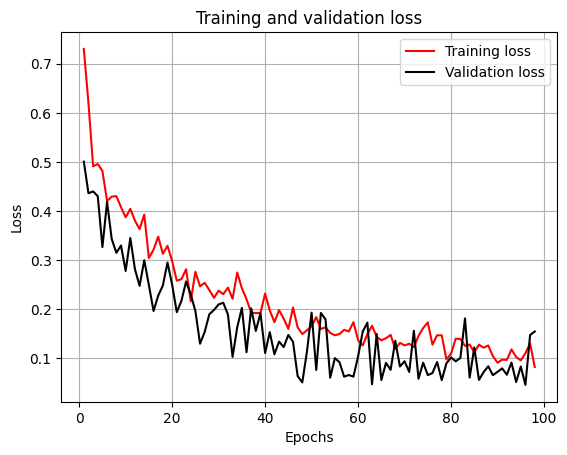

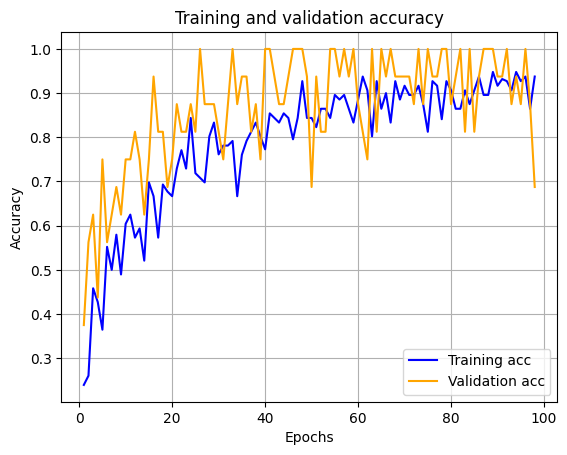

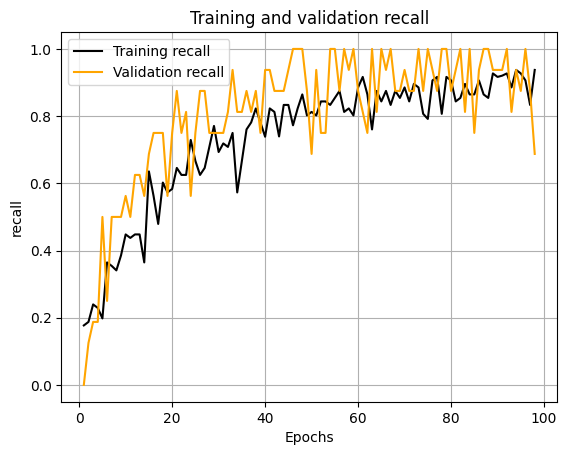

In [23]:
#plot the training and validation accuracy and loss at each epoch
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'r', label='Training loss')
epochs = range(1, len(loss) + 1)
plt.plot(epochs, val_loss, 'k', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.savefig(f'loss.png')
plt.show()

epochs = range(1, len(loss) + 1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'blue', label='Training acc')
epochs = range(1, len(loss) + 1)
plt.plot(epochs, val_acc, 'orange', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.savefig(f'acc.png')
plt.show()

epochs = range(1, len(loss) + 1)
recall = history.history['recall']
val_recall = history.history['val_recall']
plt.plot(epochs, recall, 'black', label='Training recall')
epochs = range(1, len(loss) + 1)
plt.plot(epochs, val_recall, 'orange', label='Validation recall')
plt.title('Training and validation recall')
plt.xlabel('Epochs')
plt.ylabel('recall')
plt.legend()
plt.grid()
plt.savefig(f'recall.png')
plt.show()

In [24]:
test_dir = '/media/pendrive/styleclasses/test/' 

In [25]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    # class_mode='binary')
    class_mode='categorical')

Found 200 images belonging to 5 classes.


In [26]:
scores = model.evaluate(test_generator)
# print(f"\nТочность на тестовых данных: {(scores[1]*100):.2f}%")
print(scores)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - FN: 8.0000 - FP: 7.0000 - TN: 793.0000 - TP: 192.0000 - accuracy: 0.9600 - auc: 0.9988 - loss: 0.0553 - precision: 0.9648 - recall: 0.9600
[0.055277056992053986, 0.9599999785423279, 0.9988405704498291, 0.9648241400718689, 0.9599999785423279, 192.0, 793.0, 7.0, 8.0]


In [27]:
from math import sqrt
mcc = (scores[-4]*scores[-3] - scores[-2]*scores[-1])/sqrt((scores[-4]+scores[-2])*(scores[-4]+scores[-1])*(scores[-3]+scores[-2])*(scores[-3]+scores[-1]))
print(f'Коэффициент корреляции Мэтьюса = {mcc}')

Коэффициент корреляции Мэтьюса = 0.9530416153053825


In [28]:
model.save('pretrained-classificator-styles-RsNet50-TF21GPU.keras')

In [9]:
test_dir = '/media/pendrive/styleclasses/test/'

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical')
scores = model.evaluate(test_generator)
print(scores)
mcc = (scores[-4]*scores[-3] - scores[-2]*scores[-1])/sqrt((scores[-4]+scores[-2])*(scores[-4]+scores[-1])*(scores[-3]+scores[-2])*(scores[-3]+scores[-1]))
print(f'Коэффициент корреляции Мэтьюса = {mcc}')

NameError: name 'img_width' is not defined

In [7]:
from keras import metrics

model = keras.models.load_model("pretrained-classificator-styles-RsNet50-TF21GPU.keras")
print("Loaded model from disk")

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss='binary_crossentropy', # 'categorical_crossentropy',
              metrics=['accuracy',
                       metrics.AUC(name='auc'),
                       metrics.Precision(name='precision'), 
                       metrics.TruePositives(), 
                       metrics.TrueNegatives(), 
                       metrics.FalsePositives(), 
                       metrics.FalseNegatives(),
                       metrics.Recall()])

test_dir = '/media/pendrive/styleclasses/test/'
test_datagen = ImageDataGenerator()
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=16,
    # class_mode='binary')
    class_mode='categorical')

Loaded model from disk
Found 200 images belonging to 5 classes.


In [8]:
scores = model.evaluate(test_generator)
print(model.metrics_names)
print(scores)

from math import sqrt
mcc = (scores[-4]*scores[-3] - scores[-2]*scores[-1])/sqrt((scores[-4]+scores[-2])*(scores[-4]+scores[-1])*(scores[-3]+scores[-2])*(scores[-3]+scores[-1]))
print(f'Коэффициент корреляции Мэтьюса = {mcc}')

/home/van_rossum/Документы/neurofrankenstyle/TF21GPU/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 344ms/step - accuracy: 0.9600 - auc: 0.9988 - false_negatives: 8.0000 - false_positives: 7.0000 - loss: 0.0553 - precision: 0.9648 - recall: 0.9600 - true_negatives: 793.0000 - true_positives: 192.0000
['loss', 'compile_metrics']
[0.05527493357658386, 0.9599999785423279, 0.9988405704498291, 0.9648241400718689, 192.0, 793.0, 7.0, 8.0, 0.9599999785423279]
Коэффициент корреляции Мэтьюса = 0.636139286640009


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
predictions =  [[9.9757022e-01 2.6708785e-06 2.3075940e-04 3.9127521e-05 2.1572618e-03]]
Predicted class: 1


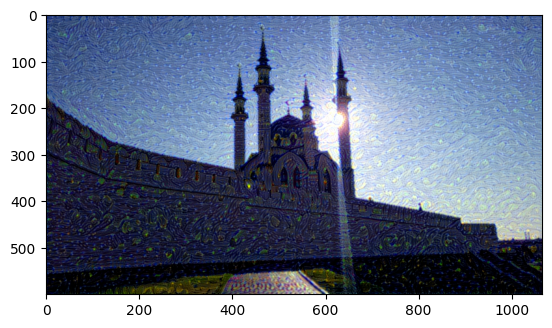

In [4]:
import numpy as np
from keras.preprocessing import image
from keras.models import load_model

# Загрузка модели
model = load_model("pretrained-classificator-styles-RsNet50-TF21GPU.keras")

# Загрузка и подготовка изображения
img_path = 'k.png'  # Укажите путь к вашему изображению

img = Image.open(img_path)
plt.imshow(img)

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча
# img_array /= 255.0  # Нормализация ухудшает предсказание, также как и при обучении

# Предсказание
predictions = model.predict(img_array)
print('predictions = ', predictions)
predicted_class = np.argmax(predictions, axis=1)
print(f'Predicted class: {predicted_class[0]+1}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
predictions =  [[3.8607564e-06 3.4161880e-07 2.0566737e-04 6.0935655e-08 9.9979007e-01]]
Predicted class: 5


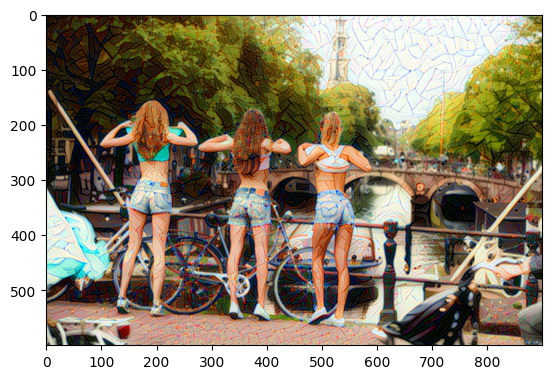

In [10]:
# Загрузка и подготовка изображения
img_path = '2_vgg19_60000_5_at_iteration_1300.png'  # Укажите путь к вашему изображению

img = Image.open(img_path)
plt.imshow(img)


img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча
# img_array /= 255.0  # Нормализация

# Предсказание
predictions = model.predict(img_array)
print('predictions = ', predictions)
predicted_class = np.argmax(predictions, axis=1)
print(f'Predicted class: {predicted_class[0]+1}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
predictions =  [[9.1235015e-06 3.5372250e-05 4.5746510e-05 9.9076301e-01 9.1467761e-03]]
Predicted class: 4


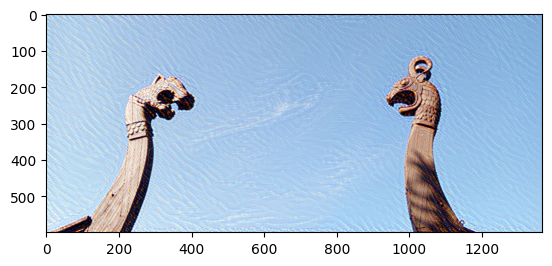

In [11]:
# Загрузка и подготовка изображения
img_path = 'Vyborg_vgg19_2000_4_at_iteration_100.png'  # Укажите путь к вашему изображению

img = Image.open(img_path)
plt.imshow(img)


img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча
# img_array /= 255.0  # Нормализация

# Предсказание
predictions = model.predict(img_array)
print('predictions = ', predictions)
predicted_class = np.argmax(predictions, axis=1)
print(f'Predicted class: {predicted_class[0]+1}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
predictions =  [[6.9127822e-01 6.7023597e-05 1.2245798e-03 1.7947495e-01 1.2795521e-01]]
Predicted class: [1 4 5 3 2]


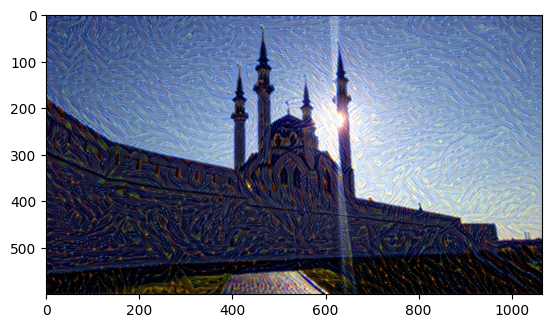

In [20]:
# Загрузка и подготовка изображения
img_path = 'k_vgg19_200_4_at_iteration_200.png'  # 1 и 4 классы

img = Image.open(img_path)
plt.imshow(img)

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча
# img_array /= 255.0  # Нормализация

# Предсказание
predictions = model.predict(img_array)
print('predictions = ', predictions)
predicted_class = np.argsort(-predictions, axis=1) # -predictions т.к. сортировка по возрастанию, а требуется по убыванию
print(f'Predicted class: {predicted_class[0]+1}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
predictions =  [[1.4250640e-04 3.1282971e-04 4.1906675e-04 9.8576498e-01 1.3360581e-02]]
Predicted class: [4 5 3 2 1]


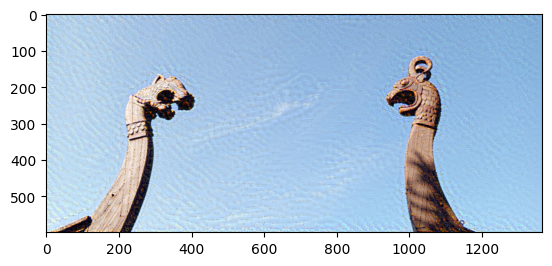

In [5]:
# Загрузка и подготовка изображения
img_path = 'Vyborg_vgg19_2000_4_at_iteration_100_vgg19_200_3_at_iteration_60.png'  # 3 и 4 классы

img = Image.open(img_path)
plt.imshow(img)

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча
# img_array /= 255.0  # Нормализация

# Предсказание
predictions = model.predict(img_array)
print('predictions = ', predictions)
predicted_class = np.argsort(-predictions, axis=1) # -predictions т.к. сортировка по возрастанию, а требуется по убыванию
print(f'Predicted class: {predicted_class[0]+1}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
predictions =  [[0.10407362 0.00425732 0.01143043 0.8220949  0.0581438 ]]
Predicted class: [4 1 5 3 2]


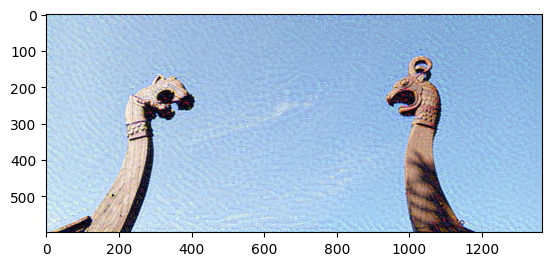

In [6]:
# Загрузка и подготовка изображения
img_path = 'Vyborg_vgg19_2000_4_at_iteration_100_vgg19_200_3_at_iteration_60_vgg19_200_1_at_iteration_140.png'  # 1, 3 и 4 классы

img = Image.open(img_path)
plt.imshow(img)

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Добавьте размерность для батча
# img_array /= 255.0  # Нормализация

# Предсказание
predictions = model.predict(img_array)
print('predictions = ', predictions)
predicted_class = np.argsort(-predictions, axis=1) # -predictions т.к. сортировка по возрастанию, а требуется по убыванию
print(f'Predicted class: {predicted_class[0]+1}')